# The generalized (Robertson) uncertainty principle
### Griffiths QM 3.4: one inequality behind Heisenberg, spin, and energy-time

The single most general statement of uncertainty: for any two observables $A, B$ in a
state $\psi$,
$$\sigma_A\,\sigma_B \ge \left|\frac{1}{2i}\langle[A,B]\rangle\right|,
\qquad [A,B]=AB-BA.$$
The commutator sets the bound. When $A,B$ **don't commute** you can't sharpen both at
once; when they **do**, the bound is zero (they share eigenstates). The famous cases
fall out:
- position-momentum, $[x,p]=i\hbar \Rightarrow \sigma_x\sigma_p\ge\hbar/2$;
- spin, $[\sigma_x,\sigma_y]=2i\sigma_z \Rightarrow \sigma_{S_x}\sigma_{S_y}\ge|\langle S_z\rangle|$.

It is all linear algebra -- operators are matrices, states are vectors. Uses
`dgs/robertson_uncertainty.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import robertson_uncertainty as ru
X, Y, Z = ru.SIGMA_X, ru.SIGMA_Y, ru.SIGMA_Z
print("[sigma_x, sigma_y] = 2i sigma_z :", np.allclose(ru.commutator(X, Y), 2j*Z))

[sigma_x, sigma_y] = 2i sigma_z : True


## 1. Position-momentum -- the Heisenberg minimum

A wavefunction and its momentum-space transform cannot both be narrow. A **Gaussian**
saturates $\sigma_x\sigma_p=\hbar/2$ (the minimum-uncertainty state); a wider Gaussian
trades spread in $x$ for sharpness in $p$ (product stays at the floor); a **chirp** adds
momentum spread and pushes the product up.

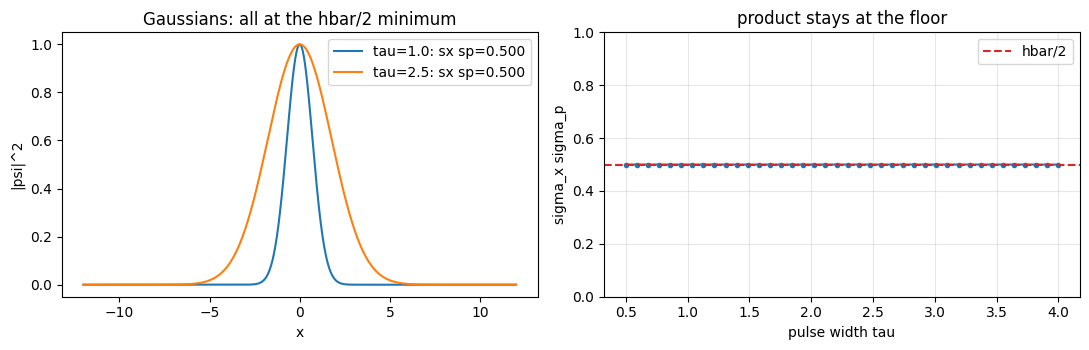

In [2]:
x = np.linspace(-12, 12, 4096)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for tau, c in [(1.0,"C0"), (2.5,"C1")]:
    g = np.exp(-x**2/(2*tau**2))
    prod, bound = ru.position_momentum_uncertainty(x, g)
    ax[0].plot(x, np.abs(g)**2/np.max(np.abs(g)**2), c, label=f"tau={tau}: sx sp={prod:.3f}")
ax[0].set(xlabel="x", ylabel="|psi|^2", title="Gaussians: all at the hbar/2 minimum"); ax[0].legend()
taus = np.linspace(0.5, 4, 40)
prods = [ru.position_momentum_uncertainty(x, np.exp(-x**2/(2*tt**2)))[0] for tt in taus]
ax[1].plot(taus, prods, "o-", ms=3); ax[1].axhline(0.5, ls="--", color="C3", label="hbar/2")
ax[1].set(xlabel="pulse width tau", ylabel="sigma_x sigma_p", title="product stays at the floor"); ax[1].legend()
ax[1].set_ylim(0, 1); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Spin -- the commutator bound, swept over the Bloch sphere

For a spin state tilted by angle $\theta$ from $+z$, $\langle\sigma_z\rangle=\cos\theta$,
so the bound $|\langle\sigma_z\rangle|=|\cos\theta|$. These states are **minimum
uncertainty** -- $\sigma_x\sigma_y$ rides exactly on the bound. A generic state sits
strictly above it: Robertson is an inequality, saturated only by special states.

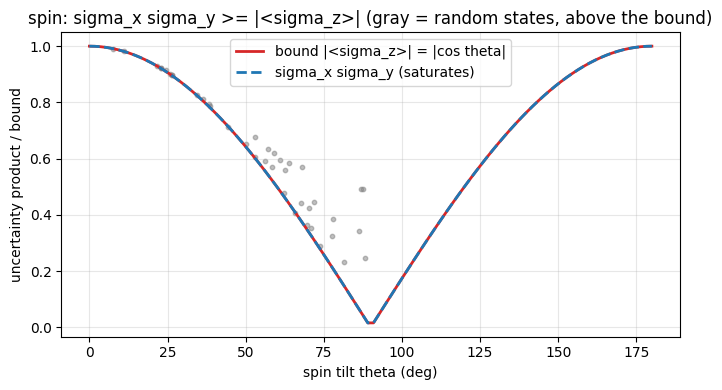

commuting case [sigma_z, sigma_z]=0 -> bound 0.0


In [3]:
theta = np.linspace(0, np.pi, 100)
prod = []; bound = []
for th in theta:
    psi = np.array([np.cos(th/2), np.sin(th/2)])         # tilt from +z toward +x
    l, r, _ = ru.check_uncertainty(X, Y, psi); prod.append(l); bound.append(r)
plt.figure(figsize=(7,4))
plt.plot(np.degrees(theta), bound, "C3", lw=2, label="bound |<sigma_z>| = |cos theta|")
plt.plot(np.degrees(theta), prod, "C0--", lw=2, label="sigma_x sigma_y (saturates)")
rng = np.random.default_rng(1)
for _ in range(40):                                       # random states: strictly above
    psi = rng.standard_normal(2) + 1j*rng.standard_normal(2)
    l, r, _ = ru.check_uncertainty(X, Y, psi); plt.scatter([np.degrees(np.arccos(np.clip(r,-1,1)))],[l], s=10, color="gray", alpha=0.5)
plt.xlabel("spin tilt theta (deg)"); plt.ylabel("uncertainty product / bound"); plt.legend()
plt.title("spin: sigma_x sigma_y >= |<sigma_z>| (gray = random states, above the bound)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("commuting case [sigma_z, sigma_z]=0 -> bound", ru.uncertainty_bound(Z, Z, [1,0]))

## 3. Which subjects from Griffiths QM you have already built

You asked what to take from this book. Mapping its table of contents onto this repo --
you have already touched most of it through the projects:

| Griffiths QM chapter | what you built here |
|---|---|
| 1. Wave function, statistical interpretation, uncertainty | `quantum_bridge` (Born rule), this notebook |
| 2. TISE: infinite well, **harmonic oscillator**, free particle, delta | `eigen_modes`, `lagrangian` (oscillator), the free particle = the dispersion operator |
| 3. **Formalism: linear algebra, generalized uncertainty** | THIS build; linear algebra runs `truss`, `spice` MNA, `bessel_linalg` |
| 4. 3D: spherical coords, **hydrogen**, **angular momentum**, **spin** | `bohr_moseley`, `bessel_linalg` (partial waves), `atomic` (spin + g-factor) |
| 5. Identical particles, atoms, **solids** | `kronig_penney` band theory (5.3 Solids), Pauli exclusion |
| 6. Perturbation theory, the **Zeeman effect**, fine structure | `atomic` (normal + anomalous Zeeman) |
| 7. **Variational principle** | `griffiths/quantum` variational energy |
| 11. **Scattering, partial-wave analysis**, Born approximation | SEALS Mie scattering = partial-wave analysis |

The gaps worth doing next: **WKB/tunneling** (Ch 8), **time-dependent perturbation /
emission** (Ch 9), and **Berry's phase** (Ch 10) -- which is literally a geometric
*phase*, close to your phase-retrieval theme.

## Takeaway

1. **Robertson** $\sigma_A\sigma_B\ge|\langle[A,B]\rangle/2i|$ is the master uncertainty
   relation; the commutator sets the bound.
2. **Heisenberg** ($\hbar/2$, saturated by a Gaussian) and **spin**
   ($|\langle\sigma_z\rangle|$, saturated on the Bloch sphere) are special cases.
3. Compatible observables **commute** -> bound 0 -> simultaneously sharp.

It is linear algebra wearing a physics hat -- and you have already met most of
Griffiths QM by building the projects. Civilian education.